# Lecture 12 — The cloud side: NETPIE as data and model backbone

**01211271 Industrial AI and IoT** · Electromechanical Manufacturing Engineering

---

Lecture 11 ended with a device that decides for itself. Every 64 ms it produces a
label, a margin, an anomaly score, the name of the feature that drove it, and a raised
flag — and it has no idea whether anybody is listening.

Today it starts talking. Two questions, and the second one is the interesting one:

1. **How little can it say, and still be useful?** Publishing every window is
   15.6 messages a second and a quarter of a gigabyte a day, per machine. We will
   measure four cheaper policies, and one of them will turn out to be almost free.
2. **What can a subscriber with history and peers see that the device cannot?** The
   device has one window and 200 KB of RAM. The cloud has two years of every machine
   in the plant. That difference is worth something specific, and we will measure how
   many months it is worth.

Because the device is already correct without the network, the network is an
optimisation problem rather than a safety one. That is a comfortable position to
design from, and it was bought by the previous four lectures.

## Learning objectives

By the end of this notebook you should be able to:

1. Design an MQTT message schema for a machine-learning uplink, and say what every
   field is for and what it costs in bytes.
2. Work out the bandwidth and storage consequences of a publish policy, for one
   machine and for a fleet, before writing the firmware.
3. Choose between periodic, decimated and event-driven publishing on measured
   evidence rather than taste.
4. Explain why sending a *statistic* beats sending *samples*, and quantify it.
5. Use NETPIE's topics, device shadow and retained messages correctly, and say what
   each one is for.
6. Retrieve a history from the platform and turn it into a training table.
7. Build a cloud-side detector that uses history and peers, and show what it catches
   that a per-window edge alarm does not.
8. Retrain a deployed alarm specification without making it worse, and name the four
   checks that stop you.

## Prerequisites

Lecture 10 (the alarm specification, its threshold and its expiry date), Lecture 11
(the device, its twelve features, the classifier, the alarm, and `worst_feature`).
The first half of the course for MQTT, topics and the device shadow.

## Running the notebook without a broker

Every cell here runs offline. Section 3 builds a small in-process stand-in for NETPIE
that reproduces topic wildcards, retained messages and the device shadow — and, unlike
a real broker, counts the exact bytes that crossed the wire. The real code, against the
real broker, is in section 9 and in the lab package.

In [1]:
import sys
import json
import time
import math

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

print("python     ", sys.version.split()[0])
for m in (np, pd, matplotlib, sklearn):
    print(f"{m.__name__:<11}", m.__version__)

plt.rcParams.update({"figure.figsize": (10.5, 3.6), "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.35,
                     "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, AQUA, VIOLET, RED = ("#2a78d6", "#eb6834", "#1baf7a",
                                   "#4a3aa7", "#e34948")
MUTED, YELLOW = "#898781", "#eda100"

python      3.11.15
numpy       2.4.4
pandas      3.0.2
matplotlib  3.10.9
sklearn     1.8.0


## 1. How little can the device say?

Start with the arithmetic, because it settles the argument before anyone has an
opinion.

In [2]:
FS, WIN, HOP = 2000, 256, 128
BYTES_PER_SAMPLE = 2

raw_bps = FS * BYTES_PER_SAMPLE
win_per_s = FS / HOP
feat_wire = 179          # measured in section 2

print(f"raw waveform            {raw_bps:10,.0f} bytes/s")
print(f"every window, 12 features {win_per_s * feat_wire:8,.0f} bytes/s")
print()
for label, bps in (("raw waveform", raw_bps),
                   ("every window", win_per_s * feat_wire)):
    print(f"{label:<22}{bps * 86400 / 1e6:10,.1f} MB per machine per day")
    print(f"{'':<22}{bps * 86400 * 365 * 40 / 1e9:10,.1f} GB per year for "
          f"40 machines")

raw waveform                 4,000 bytes/s
every window, 12 features    2,797 bytes/s

raw waveform               345.6 MB per machine per day
                         5,045.8 GB per year for 40 machines
every window               241.7 MB per machine per day
                         3,528.1 GB per year for 40 machines


Publishing the waveform is off the table and nobody needs telling. Publishing *every
window's features* looks reasonable — it is the obvious next step, it is what Lecture
11's device already computes, and it is what most students write first.

It is also **236 MB a day per machine**, which for a
40-machine plant is
**3,445 GB a year** of JSON describing machines that are
almost always fine.

The rest of this lecture is about the gap between that and what is actually needed.

> Lecture 11's rule was *features go up, not waveforms*. By the end of section 4 it
> will have one more clause.

## 2. The message

Before choosing how often to publish, decide what a message *is*. A schema is a
contract: the device promises these fields, the dashboard and the retraining script
depend on them, and changing it later means changing three things at once in a plant
you cannot reach.

Four rules, and the fourth one is the one people skip.

1. **Version it.** `"v": 1` costs six bytes and is the difference between a fleet you
   can upgrade and a fleet you cannot.
2. **Timestamp at the source.** The broker's arrival time is not the measurement time,
   and the difference is exactly the thing you are trying to reason about.
3. **Round to what you measured.** Lecture 11 showed float32 on the device gives about
   seven significant figures; the features themselves are noisier than that. Four
   significant figures is generous.
4. **Send the verdict, not only the evidence.** The device already decided. If the
   label, the score and the driver do not go up with the features, the cloud has to
   redo work the device has done — and, worse, the *cheap* policies in section 4 have
   nothing to send.

In [3]:
# the Lecture 8 feature set, in the order every model in this course expects
FEATURE_NAMES = ["mean", "rms", "std", "ptp", "crest", "kurt", "zcr",
                 "dom_freq", "e_1x", "e_2x", "e_bpfo", "e_hi"]

SCHEMA_VERSION = 1
TOPIC_FEAT = "@msg/feat"            # one window's twelve features + the verdict
TOPIC_EVENT = "@msg/event"          # something changed
TOPIC_SUMMARY = "@msg/summary"      # a minute of machine, in one message
TOPIC_SHADOW = "@shadow/data/update"   # last known state, for the dashboard

IMPULSIVE = ("kurt", "crest", "e_hi", "e_bpfo")   # the bearing signature
MIN_MARGIN = 0.25                   # below this the Lecture 11 device says so
T0 = 1789000000                     # a plausible unix epoch second, so the
                                    # measured payload sizes are the real ones


def q(v, sig=4):
    """Round to `sig` significant figures.  Sending float64 to three decimals of
    meaning is paying for noise."""
    return float(f"{float(v):.{sig}g}")


def stamp(t):
    """Device seconds -> a real unix timestamp, to the millisecond."""
    return round(T0 + float(t), 3)


def msg_feature(t, x, label, margin, score, driver, raised, dec=4):
    """One window, in full.  The message a naive design sends 15 times a second."""
    return {"v": SCHEMA_VERSION, "t": stamp(t),
            "f": [q(v, dec) for v in x],
            "l": label, "m": q(margin, 3), "a": q(score, 3),
            "d": driver, "r": int(raised)}


def msg_event(t, ev, label, margin, score, driver, raised):
    """Something changed.  No features -- the device already decided."""
    return {"v": SCHEMA_VERSION, "t": stamp(t), "e": ev,
            "l": label, "m": q(margin, 3), "a": q(score, 3),
            "d": driver, "r": int(raised)}


def msg_summary(t, n, score, raised, label, driver, n_imp=None):
    """A minute of machine: how many windows, how bad it got, what it was.

    `ni` is the number of those windows that alarmed with an impulsive driver.
    It costs about six bytes and it is the single most useful number in this
    lecture -- see section 4.
    """
    m = {"v": SCHEMA_VERSION, "t": stamp(t), "n": int(n),
         "a_med": q(np.median(score), 3), "a_max": q(np.max(score), 3),
         "r": int(np.sum(raised)), "l": label, "d": driver}
    if n_imp is not None:
        m["ni"] = int(n_imp)
    return m

In [4]:
def msg_verbose(t, x, label, margin, score, driver, raised):
    """The same content with self-documenting keys.  Measured, not dismissed."""
    return {"schema_version": SCHEMA_VERSION, "timestamp": stamp(t),
            "features": {n: q(v) for n, v in zip(FEATURE_NAMES, x)},
            "predicted_label": label, "classifier_margin": q(margin, 3),
            "anomaly_score": q(score, 3), "anomaly_driver": driver,
            "alarm_raised": bool(raised)}


def encoded(obj):
    """Exactly the bytes a client would hand to publish()."""
    return json.dumps(obj, separators=(",", ":"))

Now measure them. Not `len(payload)` — the wire. An MQTT PUBLISH carries a fixed
header, a remaining-length field, the topic string and its length prefix, and the topic
is sent *with every single message*.

In [5]:
def wire_bytes(topic, payload, qos=0):
    """Bytes on the wire for one MQTT 3.1.1 PUBLISH packet.

    Fixed header (1) + remaining-length field (1-4) + topic length prefix (2)
    + topic + packet id if qos > 0 + payload.  This is what your data plan is
    billed for, not `len(payload)`.
    """
    if isinstance(payload, str):
        payload = payload.encode()
    if isinstance(topic, str):
        topic = topic.encode()
    rest = 2 + len(topic) + (2 if qos else 0) + len(payload)
    rl = 1 if rest < 128 else 2 if rest < 16384 else 3
    return 1 + rl + rest

In [6]:
x_demo = [0.08992, 0.3202, 0.3202, 1.567, 2.875, 2.685, 0.1373,
          31.25, 0.7386, 0.07786, 0.002538, 0.06095]
common = dict(t=60.096, x=x_demo, label="normal", margin=1.47, score=2.61,
              driver="kurt", raised=1)

msgs = [
    ("verbose JSON", msg_verbose(**common), TOPIC_FEAT),
    ("short keys", msg_feature(**common), TOPIC_FEAT),
    ("event", msg_event(60.096, "raise", "normal", 1.47, 2.61, "kurt", 1), TOPIC_EVENT),
    ("minute summary", msg_summary(60.096, 938, np.array([2.6, 3.1, 1.9]),
                                   np.array([0, 1, 0]), "normal", "mean", n_imp=0),
     TOPIC_SUMMARY),
]
print(f"{'message':<16}{'payload':>9}{'wire':>7}")
for nm, m, tp in msgs:
    p = encoded(m)
    print(f"{nm:<16}{len(p):>9}{wire_bytes(tp, p):>7}")
print()
print(encoded(msg_feature(**common)))

message           payload   wire
verbose JSON          349    363
short keys            165    179
event                  86    100
minute summary         95    111

{"v":1,"t":1789000060.096,"f":[0.08992,0.3202,0.3202,1.567,2.875,2.685,0.1373,31.25,0.7386,0.07786,0.002538,0.06095],"l":"normal","m":1.47,"a":2.61,"d":"kurt","r":1}


Self-documenting keys cost
184 bytes a message.
At 15.625 windows a second that is about
248 MB
a day of readability that nothing reads — the dashboard and the retraining script both
work from the schema document, not from the key names.

Notice how small the **event** and **summary** messages are:
100 and 111 bytes against
179. They are small because the device did the work. That
is the whole of section 4 in one observation.

## 3. NETPIE, in one cell

The platform gives three things this lecture actually uses.

| | what it is | what it is for |
|---|---|---|
| **topics** | `@msg/<name>`, with `+` and `#` wildcards on the subscriber side | routing: one subscriber can take `@msg/#` from every machine |
| **the device shadow** | publish to `@shadow/data/update`, and a JSON document is merged into the device's state | the dashboard tile that says what the machine is doing *now*, without replaying history |
| **retained messages** | the broker keeps the last message on a topic | a dashboard that connects at 09:00 still sees the 08:59 state instead of a blank panel |

The difference between the shadow and a plain message is worth stating plainly: a
message is an *event in a stream*, a shadow is a *current value*. Alarm events belong
in the stream. "What is this machine doing right now" belongs in the shadow. Putting
the second one in the first is how dashboards end up replaying an hour of history to
draw one tile.

Here is enough of a broker to reason about, with one thing a real broker will not give
you: an exact byte count.

In [7]:
def topic_matches(filt, topic):
    """MQTT topic-filter matching, including `+` (one level) and `#` (rest)."""
    f, t = filt.split("/"), topic.split("/")
    for i, part in enumerate(f):
        if part == "#":
            return True
        if i >= len(t):
            return False
        if part != "+" and part != t[i]:
            return False
    return len(f) == len(t)

In [8]:
class Broker:
    """The smallest thing that behaves like NETPIE for our purposes."""

    def __init__(self):
        self.subs = []                 # (filter, callback, client)
        self.retained = {}             # topic -> payload
        self.shadow = {}               # device -> dict
        self.tx_bytes = 0
        self.tx_msgs = 0
        self.log = []                  # (t, device, topic, payload, bytes)

    # -- broker side ------------------------------------------------------
    def subscribe(self, filt, callback, client="cloud"):
        self.subs.append((filt, callback, client))
        for topic, payload in self.retained.items():
            if topic_matches(filt, topic):
                callback(topic, payload)

    def publish(self, device, topic, payload, t=None, retain=False, qos=0):
        """Publish one message.  `topic` is relative, as NETPIE clients send it."""
        if not isinstance(payload, (str, bytes)):
            payload = json.dumps(payload, separators=(",", ":"))
        n = wire_bytes(topic, payload, qos)
        self.tx_bytes += n
        self.tx_msgs += 1
        self.log.append((t if t is not None else time.time(), device, topic,
                         payload, n))

        if topic == "@shadow/data/update":
            body = json.loads(payload)
            doc = self.shadow.setdefault(device, {})
            doc.update(body.get("data", body))

        full = f"{device}/{topic}"
        if retain:
            self.retained[full] = payload
        for filt, cb, _ in self.subs:
            if topic_matches(filt, full):
                cb(full, payload)
        return n

    # -- reporting --------------------------------------------------------
    def reset(self):
        self.tx_bytes = 0
        self.tx_msgs = 0
        self.log.clear()

    def summary(self, hours=1.0):
        return {"messages": self.tx_msgs, "bytes": self.tx_bytes,
                "bytes_per_hour": self.tx_bytes / hours,
                "msgs_per_hour": self.tx_msgs / hours}

In [9]:
class Device:
    """What `net_pub.py` does on the ESP32, minus the WiFi."""

    def __init__(self, broker, device_id):
        self.broker = broker
        self.id = device_id

    def publish(self, topic, payload, t=None, retain=False):
        return self.broker.publish(self.id, topic, payload, t=t, retain=retain)

    def shadow_update(self, data, t=None):
        return self.publish("@shadow/data/update", {"data": data}, t=t)


class CloudClient:
    """What `cloud_sub.py` does in Colab, minus paho-mqtt."""

    def __init__(self, broker, name="cloud"):
        self.broker = broker
        self.name = name
        self.received = []

    def subscribe(self, filt):
        self.broker.subscribe(filt, self._on_message, client=self.name)

    def _on_message(self, topic, payload):
        try:
            body = json.loads(payload)
        except (ValueError, TypeError):
            body = payload
        self.received.append((topic, body))

    def publish(self, topic, payload, t=None):
        return self.broker.publish(self.name, topic, payload, t=t)

In [10]:
broker = Broker()
rig07 = Device(broker, "rig-07")
ops = CloudClient(broker, "cloud")
ops.subscribe("+/@msg/#")                      # every machine, every message topic

rig07.publish("@msg/event", {"v": 1, "e": "raise", "d": "kurt", "r": 1}, t=720.5)
rig07.shadow_update({"label": "bearing", "raised": 1, "driver": "kurt"}, t=721.0)
rig07.publish("@msg/summary", {"v": 1, "n": 938, "ni": 6}, t=780.0, retain=True)

print("the cloud subscriber received:")
for topic, body in ops.received:
    print("  ", topic, body)
print("\nthe device shadow (what the dashboard tile reads):")
print("  ", broker.shadow["rig-07"])
print("\nbytes on the wire so far:", broker.tx_bytes, "in", broker.tx_msgs, "messages")

late = CloudClient(broker, "dashboard-that-just-opened")
late.subscribe("+/@msg/summary")
print("\na dashboard connecting now still sees the retained summary:")
print("  ", late.received)

the cloud subscriber received:
   rig-07/@msg/event {'v': 1, 'e': 'raise', 'd': 'kurt', 'r': 1}
   rig-07/@msg/summary {'v': 1, 'n': 938, 'ni': 6}

the device shadow (what the dashboard tile reads):
   {'label': 'bearing', 'raised': 1, 'driver': 'kurt'}

bytes on the wire so far: 166 in 3 messages

a dashboard connecting now still sees the retained summary:
   [('rig-07/@msg/summary', {'v': 1, 'n': 938, 'ni': 6})]


The subscriber filter `+/@msg/#` is the shape a plant-wide service uses: `+` matches
exactly one level — the device id — and `#` matches everything below. One subscriber,
every machine, and the device id arrives as part of the topic so nothing has to be
duplicated inside the payload.

## 4. One shift, five publish policies

Now the measurement. We need a machine that runs continuously rather than in
four-second acquisitions, so `rig.py` gains one more campaign: **`make_shift`**, a
20-minute continuous run of one machine with two things happening
in it, and only one of them is a fault.

* At minute 5 the operator takes a **heavier cut**. Vibration
  amplitude rises. The machine is completely fine.
* At minute 12 a **bearing spall** starts, faint at first and
  growing for the rest of the shift.

Any honest publish policy has to survive both.

In [11]:
"""
rig.py — the rotor-rig simulator shared by Lectures 8-14
01211271 Industrial AI and IoT

Synthetic but physics-motivated vibration data for a small motor-driven rotor rig.

Rig model
---------
A 3-phase induction motor drives a rotor disc supported by two rolling-element
bearings.  A MEMS accelerometer is mounted radially on the drive-end bearing
housing and sampled at fs = 2000 Hz.

Three machine states are simulated:

  normal    : residual unbalance only -> modest 1x shaft-rate component
  imbalance : added trial mass on the disc -> large 1x component
  bearing   : outer-race spall -> periodic impulses at BPFO that ring the
              bearing housing resonance

Outer-race defect frequency, for a bearing with n = 9 balls, ball/pitch
diameter ratio d/D = 0.2 and contact angle 0:

    BPFO = (n/2) * (1 - (d/D) cos(phi)) * f_r = 4.5 * 0.8 * f_r = 3.6 * f_r

so at a nominal 30 Hz shaft rate (1800 rpm) the impulses arrive at 108 Hz.

Every run carries its own nuisance variation -- shaft speed, sensor gain,
broadband noise floor, DC bias and a structural tone.  This is what makes a
random train/test split across overlapping windows dishonest: the model can
memorise the run, not the fault.

Lecture 8 built the classification dataset from make_dataset().  Lecture 9 adds
make_speed_sweep(), a separate acquisition campaign used for the soft-sensor
thread: the rig is run across its speed range in the healthy state so that a
regression model can learn to read shaft speed off the vibration alone.
"""

import numpy as np

# ----------------------------------------------------------------- constants
FS = 2000.0                 # sampling rate, Hz
RUN_SECONDS = 4.0           # length of one acquisition run
RUNS_PER_CLASS = 16
CLASSES = ("normal", "imbalance", "bearing")

WIN = 256                   # default window length, samples (128 ms)
HOP = 128                   # 50 % overlap

F_RESONANCE = 600.0         # bearing housing resonance, Hz
TAU_RING = 0.0012           # impulse ring-down time constant, s
BPFO_RATIO = 3.6            # outer-race defect order

# Fixed analysis bands, Hz.  Shaft speed wanders over 28-32 Hz, so the bands
# are wide enough to hold the order they are named for without a tachometer.
BANDS = {
    "e_1x":   (20.0, 42.0),     # shaft rate
    "e_2x":   (48.0, 78.0),     # twice shaft rate
    "e_bpfo": (90.0, 132.0),    # outer-race defect order
    "e_hi":   (400.0, 900.0),   # housing resonance region
}

FEATURE_NAMES = [
    "mean", "rms", "std", "ptp", "crest", "kurt", "zcr",
    "dom_freq", "e_1x", "e_2x", "e_bpfo", "e_hi",
]


# ------------------------------------------------------------ signal synthesis
def _run_params(rng, state):
    """Nuisance parameters that vary from one acquisition run to the next."""
    return dict(
        f_r=rng.uniform(28.0, 32.0),          # shaft rate, Hz
        gain=rng.uniform(0.85, 1.25),         # sensor / mounting gain
        noise=rng.uniform(0.04, 0.20),        # broadband floor, g rms
        bias=rng.uniform(-0.06, 0.06),        # accelerometer DC offset, g
        f_struct=rng.uniform(150.0, 700.0),   # frame resonance -- a confounder
        a_struct=rng.uniform(0.03, 0.15),
        a_1x=(rng.uniform(0.20, 0.38) if state != "imbalance"
              else rng.uniform(0.58, 1.10)),
        a_imp=(rng.uniform(0.45, 1.40) if state == "bearing" else 0.0),
    )


def _synth(rng, p, seconds=RUN_SECONDS, fs=FS):
    """Turn a parameter dict into a waveform.  Shared by every campaign."""
    n = int(seconds * fs)
    t = np.arange(n) / fs

    ph = rng.uniform(0, 2 * np.pi, 4)
    x = (p["a_1x"] * np.sin(2 * np.pi * p["f_r"] * t + ph[0])
         + 0.32 * p["a_1x"] * np.sin(2 * np.pi * 2 * p["f_r"] * t + ph[1])
         + 0.12 * p["a_1x"] * np.sin(2 * np.pi * 3 * p["f_r"] * t + ph[2])
         + p["a_struct"] * np.sin(2 * np.pi * p["f_struct"] * t + ph[3]))

    if p["a_imp"] > 0:
        f_bpfo = BPFO_RATIO * p["f_r"]
        period = fs / f_bpfo
        k = 0
        while True:
            # 1 % random slip, as real rolling elements do
            idx = int(k * period * (1.0 + rng.normal(0, 0.01)))
            if idx >= n:
                break
            tail = np.arange(n - idx) / fs
            ring = (p["a_imp"] * rng.uniform(0.75, 1.25)
                    * np.exp(-tail / TAU_RING)
                    * np.sin(2 * np.pi * F_RESONANCE * tail))
            x[idx:] += ring
            k += 1

    x = p["gain"] * (x + rng.normal(0, p["noise"], n)) + p["bias"]
    return x.astype(np.float64)


def make_run(rng, state, seconds=RUN_SECONDS, fs=FS):
    """Synthesise one acquisition run.  Returns (signal, params)."""
    p = _run_params(rng, state)
    return _synth(rng, p, seconds, fs), p


def make_dataset(seed=7, runs_per_class=RUNS_PER_CLASS):
    """All runs.  Returns list of dicts with signal, label and run id."""
    rng = np.random.default_rng(seed)
    runs, rid = [], 0
    for state in CLASSES:
        for _ in range(runs_per_class):
            x, p = make_run(rng, state)
            runs.append({"x": x, "label": state, "run": rid, "params": p})
            rid += 1
    return runs


# ------------------------------------------------------------------- features
def frame(x, win=WIN, hop=HOP):
    """Slice a 1-D signal into overlapping windows -> (n_windows, win)."""
    n = 1 + (len(x) - win) // hop
    idx = np.arange(win)[None, :] + hop * np.arange(n)[:, None]
    return x[idx]


def time_features(w):
    """Seven time-domain features for each row of w."""
    mean = w.mean(axis=1)
    ac = w - mean[:, None]                      # remove DC before anything else
    rms = np.sqrt((ac ** 2).mean(axis=1))
    std = ac.std(axis=1)
    ptp = np.ptp(w, axis=1)
    peak = np.abs(ac).max(axis=1)
    crest = peak / np.maximum(rms, 1e-12)
    m4 = (ac ** 4).mean(axis=1)
    kurt = m4 / np.maximum(rms, 1e-12) ** 4     # non-excess kurtosis; 3.0 = Gaussian
    zc = np.diff(np.signbit(ac).astype(np.int8), axis=1)
    zcr = np.abs(zc).sum(axis=1) / (w.shape[1] - 1)
    return np.column_stack([mean, rms, std, ptp, crest, kurt, zcr])


def freq_features(w, fs=FS, normalise=True):
    """Dominant frequency plus four band energies.

    normalise=True gives each band as a fraction of the window's total power,
    which makes the feature independent of sensor gain.  normalise=False gives
    the absolute band power, whose units and magnitude differ wildly from the
    time-domain features -- useful for showing when feature scaling matters.
    """
    n = w.shape[1]
    win = np.hanning(n)
    ac = w - w.mean(axis=1, keepdims=True)
    spec = np.abs(np.fft.rfft(ac * win, axis=1)) ** 2
    f = np.fft.rfftfreq(n, 1.0 / fs)
    spec[:, 0] = 0.0                            # DC carries no information here
    total = np.maximum(spec.sum(axis=1), 1e-20)

    dom = f[spec.argmax(axis=1)]
    cols = [dom]
    for lo, hi in BANDS.values():
        m = (f >= lo) & (f < hi)
        band = spec[:, m].sum(axis=1)
        cols.append(band / total if normalise else band)
    return np.column_stack(cols)


def features_of(w, fs=FS, normalise=True):
    """Full 12-feature vector for each row of w."""
    return np.column_stack([time_features(w), freq_features(w, fs, normalise)])


def build_table(runs, win=WIN, hop=HOP, fs=FS, normalise=True):
    """Turn the raw runs into the (X, y, groups) learning problem."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(features_of(w, fs, normalise))
        y += [r["label"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


def raw_table(runs, win=WIN, hop=HOP):
    """The naive alternative: the raw samples of each window as the features."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(w)
        y += [r["label"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


# ------------------------------------------------- Lecture 9: the speed sweep
SWEEP_RUNS = 40
SWEEP_FR = (22.0, 40.0)     # stays inside the e_1x band (20-42 Hz)


def make_speed_sweep(seed=11, n_runs=SWEEP_RUNS, seconds=RUN_SECONDS):
    """A healthy-machine speed sweep, for the virtual tachometer.

    The rig has no tachometer.  To build one in software you run the machine
    across its speed range in a known-good state and record the true shaft
    speed from the drive's own setpoint.  Each run still carries its own gain,
    noise floor, bias and frame resonance -- the soft sensor has to work in
    spite of those, not because of them.

    Returns a list of dicts with the signal, the true shaft speed and a run id.
    """
    rng = np.random.default_rng(seed)
    runs = []
    for rid in range(n_runs):
        p = _run_params(rng, "normal")
        p["f_r"] = float(rng.uniform(*SWEEP_FR))
        x = _synth(rng, p, seconds, FS)
        runs.append({"x": x, "f_r": p["f_r"],
                     "run": rid, "params": p})
    return runs


def build_speed_table(runs, win=WIN, hop=HOP, fs=FS):
    """(X, y, groups) for the soft sensor.  y is the true shaft speed in Hz."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(features_of(w, fs))
        y += [r["f_r"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


# =========================================== Lecture 10: the fleet campaign
# A year of monitoring across a fleet of nominally identical rigs.  Faults are
# RARE, and the ones you catch early are mild -- which is the whole point of
# catching them early, and the reason recall is hard.
FLEET_N = {"normal": 132, "imbalance": 12, "bearing": 6}


def _fleet_params(rng, state):
    """Run parameters for the fleet.  Fault severity spans incipient to severe."""
    p = _run_params(rng, state)
    if state == "imbalance":
        # a light trial mass barely shifts 1x; a thrown blade is unmistakable
        p["a_1x"] = float(rng.uniform(0.42, 1.10))
    if state == "bearing":
        # an early spall rings faintly; a spalled race is loud
        p["a_imp"] = float(rng.uniform(0.22, 1.40))
    return p


def make_fleet(seed=23, counts=None, seconds=RUN_SECONDS, fs=FS):
    """One acquisition per machine per month, across a fleet.

    Returns runs in a shuffled order with a 'label' and a 'severity' field.
    Prevalence is industrial, not academic: most machines are fine, a few have
    imbalance, and bearing spalls are rarer still.
    """
    counts = counts or FLEET_N
    rng = np.random.default_rng(seed)
    runs, rid = [], 0
    for state, n in counts.items():
        for _ in range(n):
            p = _fleet_params(rng, state)
            x = _synth(rng, p, seconds, fs)
            sev = (p["a_1x"] if state == "imbalance"
                   else p["a_imp"] if state == "bearing" else 0.0)
            runs.append({"x": x, "label": state, "run": rid,
                         "severity": float(sev), "params": p})
            rid += 1
    order = rng.permutation(len(runs))
    return [runs[i] for i in order]


# ============================================ Lecture 10: the drift campaign
# The same healthy machine, measured monthly for four years.  Nothing breaks --
# but the sensor mount relaxes, the ambient noise floor rises and the frame
# resonance walks.  A threshold set in the first year will not survive.
def make_drift_campaign(seed=31, n_months=48, fault_from=42, seconds=RUN_SECONDS,
                        fs=FS):
    """Healthy runs in time order with a slow baseline drift, then a real fault.

    Each run carries 'month'.  Runs from `fault_from` onward are a genuine
    bearing spall, so the last months contain something a detector SHOULD fire
    on -- everything before that is a healthy machine that merely looks
    different from how it looked in month 0.
    """
    rng = np.random.default_rng(seed)
    runs = []
    for m in range(n_months):
        t = m / (n_months - 1)                       # 0 -> 1 over the campaign
        faulty = m >= fault_from
        p = _run_params(rng, "bearing" if faulty else "normal")
        p["noise"] = float(0.06 + 0.050 * t + rng.normal(0, 0.005))
        p["a_struct"] = float(0.04 + 0.045 * t + rng.normal(0, 0.004))
        p["f_struct"] = float(180.0 + 110.0 * t + rng.normal(0, 8.0))
        p["gain"] = float(1.0 + 0.10 * t + rng.normal(0, 0.015))
        if faulty:
            p["a_imp"] = 1.10
        x = _synth(rng, p, seconds, fs)
        runs.append({"x": x, "label": "bearing" if faulty else "normal",
                     "run": m, "month": m, "params": p})
    return runs


# ======================================== Lecture 12: one shift, continuously
# Lectures 8-11 worked in 4-second acquisitions.  A device that is deployed does
# not take acquisitions -- it runs.  This campaign is one machine monitored
# without interruption through a shift, so that "how often should it publish?"
# becomes a question with a measurable answer.
#
# Two things happen during the shift and only one of them is a fault:
#
#   * a LOAD CHANGE at `load_at_min` -- the operator takes a heavier cut.  The
#     machine is fine.  Vibration amplitude rises anyway, which is exactly what
#     a fixed dashboard threshold on rms will fire on.
#   * a BEARING SPALL from `fault_at_min`, growing in severity.  This is the
#     thing worth telling anybody about.
SHIFT_SEG = 4.0             # seconds of signal synthesised at a time


def make_shift(seed=53, minutes=20.0, load_at_min=5.0, load_until_min=9.0,
               fault_at_min=12.0, fs=FS, win=WIN, hop=HOP):
    """A continuous run of one machine.  Returns the FEATURE STREAM, not samples.

    Returns a dict with:
        X          (n_windows, 12) features, in FEATURE_NAMES order
        t          window start time, seconds from the start of the shift
        state      per-window ground truth: 'normal' | 'loaded' | 'bearing'
        fault_at   seconds at which the spall begins
        load_at    (start, end) seconds of the heavy cut
        hop_s      seconds between consecutive windows
    """
    rng = np.random.default_rng(seed)
    n_seg = int(round(minutes * 60.0 / SHIFT_SEG))
    base = _run_params(rng, "normal")

    X, tt, st = [], [], []
    for k in range(n_seg):
        t0 = k * SHIFT_SEG
        p = dict(base)
        # slow wander that a real machine has and a 4-second acquisition hides
        p["f_r"] = base["f_r"] + 0.6 * np.sin(2 * np.pi * t0 / 420.0) + rng.normal(0, 0.05)
        p["noise"] = base["noise"] * float(rng.uniform(0.94, 1.06))

        loaded = load_at_min * 60.0 <= t0 < load_until_min * 60.0
        if loaded:
            p["a_1x"] = base["a_1x"] * 1.85       # heavier cut, healthy machine
            p["gain"] = base["gain"] * 1.10

        sev = 0.0
        if t0 >= fault_at_min * 60.0:
            # the spall grows: barely audible at onset, unmistakable by the end
            frac = (t0 - fault_at_min * 60.0) / max(
                1e-9, minutes * 60.0 - fault_at_min * 60.0)
            sev = 0.18 + 1.05 * frac
            p["a_imp"] = float(sev)

        x = _synth(rng, p, SHIFT_SEG, fs)
        w = frame(x, win, hop)
        f = features_of(w, fs)
        X.append(f)
        tt.append(t0 + np.arange(len(f)) * hop / fs)
        st += [("bearing" if sev > 0 else "loaded" if loaded else "normal")] * len(f)

    return {"X": np.vstack(X), "t": np.concatenate(tt), "state": np.array(st),
            "fault_at": fault_at_min * 60.0,
            "load_at": (load_at_min * 60.0, load_until_min * 60.0),
            "hop_s": hop / fs, "minutes": minutes}


# ==================================== Lecture 12: a fleet, measured for 2 years
# One acquisition per machine per month.  Two effects are superimposed and
# telling them apart is the whole cloud-side argument:
#
#   * a PLANT-WIDE ambient change -- every machine's noise floor creeps up as
#     the building fills with new equipment.  Common mode.  Nothing is wrong.
#   * ONE machine developing a bearing spall so slowly that no single monthly
#     acquisition looks alarming until it is nearly too late.
MONTH_MACHINES = 12
MONTH_MONTHS = 24


def make_month_campaign(seed=61, n_machines=MONTH_MACHINES, n_months=MONTH_MONTHS,
                        degrader=7, degrade_from=8, seconds=RUN_SECONDS, fs=FS):
    """Monthly acquisitions from a small fleet.  Returns a list of run dicts.

    Each run carries 'machine', 'month', 'label' and 'severity'.
    """
    rng = np.random.default_rng(seed)
    # every machine has its own fixed personality: mounting, gain, resonance
    ident = []
    for m in range(n_machines):
        q = _run_params(rng, "normal")
        ident.append(q)

    runs = []
    for month in range(n_months):
        u = month / (n_months - 1)
        ambient = 1.0 + 0.38 * u                 # common mode, plant-wide
        for m in range(n_machines):
            p = dict(ident[m])
            p["noise"] = float(ident[m]["noise"] * ambient
                               * rng.uniform(0.96, 1.04))
            p["f_r"] = float(ident[m]["f_r"] + rng.normal(0, 0.25))
            p["gain"] = float(ident[m]["gain"] * rng.uniform(0.97, 1.03))
            p["a_1x"] = float(ident[m]["a_1x"] * rng.uniform(0.94, 1.06))

            sev = 0.0
            if m == degrader and month >= degrade_from:
                frac = (month - degrade_from) / max(1, n_months - 1 - degrade_from)
                sev = 0.15 + 1.35 * frac
                p["a_imp"] = float(sev)
            x = _synth(rng, p, seconds, fs)
            runs.append({"x": x, "machine": m, "month": month,
                         "label": "bearing" if sev > 0 else "normal",
                         "severity": float(sev), "params": p})
    return runs


def build_month_table(runs, win=WIN, hop=HOP, fs=FS):
    """One row per window, with machine and month carried alongside."""
    X, mach, mon, lab, sev = [], [], [], [], []
    for r in runs:
        f = features_of(frame(r["x"], win, hop), fs)
        X.append(f)
        mach += [r["machine"]] * len(f)
        mon += [r["month"]] * len(f)
        lab += [r["label"]] * len(f)
        sev += [r["severity"]] * len(f)
    return (np.vstack(X), np.array(mach), np.array(mon), np.array(lab),
            np.array(sev))

In [12]:
import rig

sh = rig.make_shift(seed=53, minutes=20.0)
t, X = sh["t"], sh["X"]
print(f"{len(t):,} windows over {sh['minutes']:.0f} minutes, "
      f"one every {sh['hop_s'] * 1000:.0f} ms")
print("ground truth:", {s: int((sh['state'] == s).sum()) for s in ('normal', 'loaded', 'bearing')})

18,300 windows over 20 minutes, one every 64 ms
ground truth: {'normal': 7320, 'loaded': 3660, 'bearing': 7320}


The device is the one from Lecture 11 — the folded classifier, the alarm, the 3-of-5
persistence rule, the driver name — written in NumPy so we can run twenty minutes of it
in a second.

In [13]:
class EdgeDevice:
    """The Lecture 11 device: classifier, alarm, persistence rule, driver name."""

    def __init__(self, model_json, alarm_json):
        clf = json.load(open(model_json)) if isinstance(model_json, str) else model_json
        alm = json.load(open(alarm_json)) if isinstance(alarm_json, str) else alarm_json
        mu, sd = np.array(clf["scaler_mean"]), np.array(clf["scaler_scale"])
        W, b = np.array(clf["coef"]), np.array(clf["intercept"])
        self.W = W / sd                                  # the Lecture 11 fold
        self.b = b - (W * (mu / sd)).sum(axis=1)
        self.classes = list(clf["classes"])
        self.amu = np.array(alm["scaler_mean"])
        self.ainv = 1.0 / np.array(alm["scaler_scale"])
        self.names = list(alm["feature_names"])
        self.threshold = float(alm["threshold"])
        self.m = int(alm["persistence"]["m"])
        self.n = int(alm["persistence"]["n"])

    def run(self, X):
        """Decide on every window.  Returns a dict of per-window arrays."""
        S = X @ self.W.T + self.b
        best = S.argmax(1)
        part = np.partition(S, -2, axis=1)
        margin = part[:, -1] - part[:, -2]
        label = np.array(self.classes, dtype=object)[best]
        label = np.where(margin < MIN_MARGIN, "uncertain", label)

        Z = np.abs((X - self.amu) * self.ainv)
        score = Z.max(1)
        driver = np.array(self.names, dtype=object)[Z.argmax(1)]

        over = (score > self.threshold).astype(int)
        raised = np.zeros(len(X), dtype=bool)
        hist = np.zeros(self.n, dtype=int)
        for i, o in enumerate(over):
            hist[i % self.n] = o
            raised[i] = hist.sum() >= self.m
        return {"label": label, "margin": margin, "score": score,
                "driver": driver, "raised": raised, "over": over.astype(bool)}

In [14]:
dev = EdgeDevice("lecture9_model.json", "lecture10_alarm.json")
D = dev.run(X)

print(f"windows that raised the alarm: {D['raised'].mean():.1%}")
tm = t / 60.0
for name, lo, hi in (("before anything", 0, sh["load_at"][0] / 60),
                     ("the heavy cut", sh["load_at"][0] / 60, sh["load_at"][1] / 60),
                     ("after the spall", sh["fault_at"] / 60, sh["minutes"])):
    s = (tm >= lo) & (tm < hi)
    drv = D["driver"][s][D["raised"][s]]
    top = max(set(drv), key=list(drv).count) if len(drv) else "-"
    print(f"  {name:<18} raised {D['raised'][s].mean():6.1%}   "
          f"driven mostly by {top}")

windows that raised the alarm: 27.1%
  before anything    raised   0.3%   driven mostly by dom_freq
  the heavy cut      raised 100.0%   driven mostly by rms
  after the spall    raised  17.5%   driven mostly by kurt


Read that table before going on. The healthy load change raises the alarm on **every
window**, driven by `rms`. The spall raises it far less often at first, and when it does,
the driver is `kurt` or `crest`.

The alarm alone cannot tell these apart. The alarm **plus the driver name** can — which
is why Lecture 11's `worst_feature()` returns a name, and why `"d"` is in the schema.

### The five policies

| policy | what it sends |
|---|---|
| **every window** | one feature message per window, 15.6 a second |
| **1 in 16** | one window in sixteen, about one a second |
| **on change + heartbeat** | an event when the situation changes, and one summary a minute |
| **on alarm + context** | the same, plus a burst of raw feature messages around each alarm |
| **counting heartbeat** | on-change, with one extra integer in the heartbeat |

Two pieces of alarm management make the event-driven policies usable rather than a
storm: a **debounce** (the state must hold for 32 windows, about two seconds, before it
is believed) and a **dwell** (at most one event every 15 seconds). The 3-of-5
persistence rule from Lecture 10 was tuned for driving an actuator; as a *reporting*
rule it chatters about fifteen times a second.

In [15]:
def policy_every(t, dev, X, **kw):
    """Send every window.  The default a student writes on the first attempt."""
    return [(t[i], TOPIC_FEAT,
             msg_feature(t[i], X[i], dev["label"][i], dev["margin"][i],
                         dev["score"][i], dev["driver"][i], dev["raised"][i]))
            for i in range(len(t))]


def policy_decimate(t, dev, X, every=16, **kw):
    """Send one window in `every`.  Cheaper, and blind in between."""
    return [(t[i], TOPIC_FEAT,
             msg_feature(t[i], X[i], dev["label"][i], dev["margin"][i],
                         dev["score"][i], dev["driver"][i], dev["raised"][i]))
            for i in range(0, len(t), every)]


def _modal(a):
    a = list(a)
    return max(set(a), key=a.count)


def _minute_blocks(t, heartbeat):
    edges = np.arange(0.0, t[-1] + heartbeat, heartbeat)
    return np.clip(np.searchsorted(edges, t, side="right") - 1, 0, None)


def family(driver):
    """Which kind of thing is driving the alarm.

    Two families is enough, and the split is the physics: impulsive features
    move when a rolling element hits a defect; amplitude features move when the
    operator takes a heavier cut.  A device that reports only `raised` cannot
    tell the cloud which of those just happened.
    """
    return "impulsive" if driver in IMPULSIVE else "amplitude"


def policy_on_change(t, dev, X, heartbeat=60.0, smooth=32, dwell=15.0,
                     count_impulsive=False, **kw):
    """Publish when the SITUATION changes, plus a heartbeat so that silence is
    not indistinguishable from a dead device.

    The situation is (alarm raised or not, which family of feature is driving
    it).  Two pieces of alarm management make this usable instead of a storm:

      * `smooth` -- the state is the majority over the last `smooth` windows
        (about two seconds), not the instantaneous flag.  The 3-of-5 persistence
        rule was tuned in Lecture 10 for driving an actuator, and it chatters
        far too fast to be a reporting rule.
      * `dwell`  -- at most one event every `dwell` seconds.  An alarm system
        that can emit 15 events a second is an alarm system nobody reads.
    """
    out = []
    raised = dev["raised"].astype(bool)
    fam = np.array([family(d) for d in dev["driver"]], dtype=object)
    published, last_t = (False, None), -1e9
    for i in range(smooth, len(t)):
        sl = slice(i - smooth, i)
        r = raised[sl].mean() > 0.5
        if r:
            f = fam[sl][raised[sl]]
            state = (True, max(set(f), key=list(f).count))
        else:
            state = (False, None)
        if state != published and (t[i] - last_t) >= dwell:
            ev = ("raise" if state[0] and not published[0]
                  else "clear" if published[0] and not state[0] else "driver")
            d = dev["driver"][sl][raised[sl]] if r else dev["driver"][sl]
            out.append((t[i], TOPIC_EVENT,
                        msg_event(t[i], ev, _modal(dev["label"][sl]),
                                  np.median(dev["margin"][sl]),
                                  np.median(dev["score"][sl]),
                                  _modal(d), state[0])))
            published, last_t = state, t[i]

    blk = _minute_blocks(t, heartbeat)
    for b in np.unique(blk):
        sel = blk == b
        i_end = int(np.flatnonzero(sel)[-1])
        drv = dev["driver"][sel][raised[sel]] if raised[sel].any() else dev["driver"][sel]
        ni = (int(np.sum(raised[sel] & np.isin(dev["driver"][sel], IMPULSIVE)))
              if count_impulsive else None)
        out.append((t[i_end], TOPIC_SUMMARY,
                    msg_summary(t[i_end], sel.sum(), dev["score"][sel],
                                dev["raised"][sel], _modal(dev["label"][sel]),
                                _modal(drv), n_imp=ni)))
    out.sort(key=lambda r: r[0])
    return out


def policy_on_alarm_context(t, dev, X, heartbeat=60.0, burst=8, **kw):
    """Heartbeat and events, plus the raw windows around every raise so the
    cloud can run its own model on the evidence instead of trusting a verdict."""
    out = policy_on_change(t, dev, X, heartbeat=heartbeat, **kw)
    fires = [i for i, (tm, tp, b) in enumerate(out)
             if tp == TOPIC_EVENT and b.get("r")]
    for k in fires:
        tm = out[k][0]
        j = int(np.searchsorted(t, tm))
        lo = max(0, j - burst)
        for i in range(lo, min(len(t), lo + burst)):
            out.append((t[i], TOPIC_FEAT,
                        msg_feature(t[i], X[i], dev["label"][i],
                                    dev["margin"][i], dev["score"][i],
                                    dev["driver"][i], dev["raised"][i])))
    out.sort(key=lambda r: r[0])
    return out


def policy_counting(t, dev, X, **kw):
    """Events and a heartbeat, and the heartbeat carries a COUNT of the windows
    that alarmed impulsively.  The device sends the statistic, not the samples."""
    kw = dict(kw)
    kw["count_impulsive"] = True
    return policy_on_change(t, dev, X, **kw)


POLICIES = {
    "every window": policy_every,
    "1 in 16": policy_decimate,
    "on change + heartbeat": policy_on_change,
    "on alarm + context": policy_on_alarm_context,
    "counting heartbeat": policy_counting,
}

### One rule for the cloud, applied to all five

The comparison is only meaningful if the cloud's decision rule does not change between
policies. Here it is:

> Raise a bearing alert as soon as **three** of the messages received in the last
> **120 seconds** report an alarm whose driver is an impulsive feature.

Three, not one, because the spall is faint when it starts and kurtosis is a fourth
moment — a single impulsive window is noise. Impulsive-driver-only, because the healthy
load change raises the alarm with `rms` and the cloud must not be fooled by it.

The counting heartbeat gets to contribute its `ni` count directly, which is the entire
trick.

In [16]:
def cloud_detects(msgs, fault_at, k=3, window_s=120.0):
    """Seconds from the spall starting to the cloud raising a work order.

    ONE rule, applied to every policy, so the comparison is about information
    and not about cleverness:

        raise a bearing alert as soon as `k` of the messages received in the
        last `window_s` seconds report an alarm whose driver is an impulsive
        feature.

    A single impulsive window is noise -- the spall is faint when it starts, and
    kurtosis is a fourth moment.  Three within two minutes is a pattern.  The
    load change earlier in the shift also raises the alarm, but its driver is
    `rms`, so this rule never sees it: that is the entire reason `driver` is in
    the schema.
    """
    hits = []
    for tm, topic, body in msgs:
        n = 0
        if body.get("r", 0) and body.get("d") in IMPULSIVE:
            n = 1
        n = max(n, int(body.get("ni", 0)))       # a counting heartbeat
        if n:
            hits += [tm] * n
            hits = [h for h in hits if h >= tm - window_s]
            if len(hits) >= k:
                return tm - fault_at
    return None


def cloud_false_alerts(msgs, before, k=3, window_s=120.0):
    """Would the same rule have fired before the spall existed?"""
    pre = [m for m in msgs if m[0] < before]
    return 0 if cloud_detects(pre, 0.0, k, window_s) is None else 1


def run_policy(name, t, dev, X, broker, device_id="rig-07", hours=None, **kw):
    """Publish a whole shift under one policy and report what it cost."""
    broker.reset()
    msgs = POLICIES[name](t, dev, X, **kw)
    for tm, topic, body in msgs:
        broker.publish(device_id, topic, body, t=tm)
    hours = hours if hours is not None else (t[-1] - t[0]) / 3600.0
    s = broker.summary(hours)
    s["policy"] = name
    return s, msgs

In [17]:
broker = Broker()
HOURS = (t[-1] - t[0]) / 3600.0
rows = []
STREAMS = {}
for name in POLICIES:
    s, msgs = run_policy(name, t, D, X, broker, hours=HOURS)
    d = cloud_detects(msgs, sh["fault_at"])
    rows.append({"policy": name, "messages": s["messages"],
                 "feature msgs": sum(1 for m in msgs if m[1] == TOPIC_FEAT),
                 "bytes/hour": round(s["bytes_per_hour"]),
                 "MB/day": round(s["bytes_per_hour"] * 24 / 1e6, 2),
                 "detect (min)": round(d / 60.0, 2) if d is not None else None,
                 "false alerts": cloud_false_alerts(msgs, sh["fault_at"])})
    STREAMS[name] = msgs

tbl = pd.DataFrame(rows).set_index("policy")
print(tbl.to_string())

                       messages  feature msgs  bytes/hour  MB/day  detect (min)  false alerts
policy                                                                                       
every window              18300         18300     9832215  235.97          0.03             0
1 in 16                    1144          1144      614833   14.76          5.29             0
on change + heartbeat        31             0        9796    0.24          6.00             0
on alarm + context           87            56       39878    0.96          6.00             0
counting heartbeat           31             0       10234    0.25          1.00             0


### What that table says

**Every window** detects the spall essentially the moment it starts, and costs
236 MB a day. (Slightly less than section 1's estimate,
because not every message is as long as the representative one we measured — which is
itself a reason to measure a stream rather than extrapolate from a sample.)

**1 in 16** is sixteen times cheaper and
5.3 minutes slower. That looks like a reasonable trade until
you see the next row.

**On change + heartbeat** sends 31 messages in
twenty minutes instead of 18,300 —
1,004×
fewer bytes — and detects at 6.0 minutes. It
beats decimation on **both** axes, which means decimation is not on the frontier at all:
it is simply a worse choice, and it is the one most people reach for first.

**On alarm + context** adds 56 raw feature
messages around each alarm. It does not detect any sooner — but it is the only cheap
policy that gives the cloud the *evidence* rather than the device's verdict, which is
what section 7 needs.

**Counting heartbeat** is the answer. Same
31 messages as on-change; the heartbeat carries one
extra integer, `ni`, the number of windows in that minute that alarmed with an impulsive
driver. Six bytes. Detection goes from
6.0 minutes to
1.0 — **one heartbeat** — at
961× fewer bytes than sending everything.

> Lecture 11: *features go up, not waveforms.*
> Lecture 12: **statistics go up, not samples.**
>
> And the detection latency of a counting heartbeat is one heartbeat interval, whatever
> the window rate. That is a design knob, not an accident.

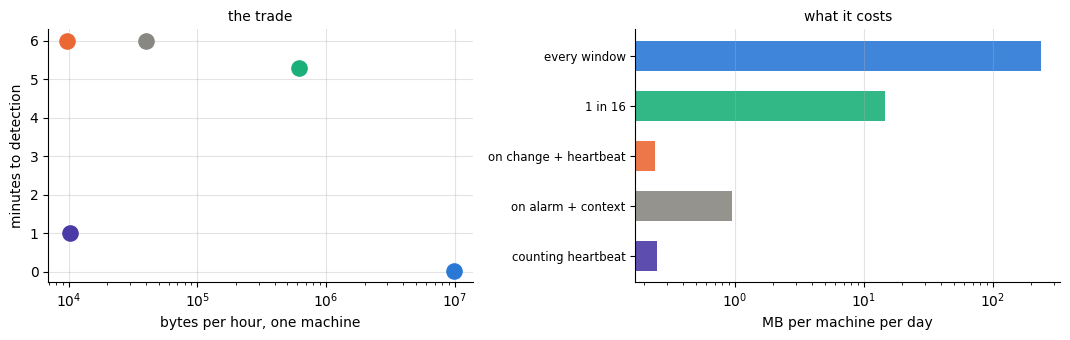

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10.8, 3.5))
COL = {"every window": BLUE, "1 in 16": AQUA, "on change + heartbeat": ORANGE,
       "on alarm + context": MUTED, "counting heartbeat": VIOLET}
for r in rows:
    ax[0].scatter(r["bytes/hour"], r["detect (min)"], s=120,
                  color=COL[r["policy"]], zorder=3)
ax[0].set_xscale("log")
ax[0].set_xlabel("bytes per hour, one machine")
ax[0].set_ylabel("minutes to detection")
ax[0].set_title("the trade", fontsize=10)

names = [r["policy"] for r in rows]
ys = np.arange(len(names))[::-1]
ax[1].barh(ys, [r["MB/day"] for r in rows], 0.6,
           color=[COL[n] for n in names], alpha=0.9)
ax[1].set_xscale("log")
ax[1].set_yticks(ys)
ax[1].set_yticklabels(names, fontsize=8.5)
ax[1].set_xlabel("MB per machine per day")
ax[1].grid(axis="y", visible=False)
ax[1].set_title("what it costs", fontsize=10)
fig.tight_layout()
plt.show()

## 5. Dashboards: a fixed threshold against a model-based alert

NETPIE will happily give you an alert rule of the form *"notify me when rms exceeds
0.35"*. It takes one minute to set up, it needs no machine learning, and on this shift
it is wrong.

In [19]:
FEATURES = rig.FEATURE_NAMES
rms = X[:, FEATURES.index("rms")]
FIXED = float(np.quantile(rms[t < sh["load_at"][0]], 0.999))   # 99.9 % of a quiet start

load = (t >= sh["load_at"][0]) & (t < sh["load_at"][1])
spall = t >= sh["fault_at"]
print(f"fixed threshold on rms: {FIXED:.3f} g")
print(f"  fires on {rms[load].mean() > FIXED and 1.0 or (rms[load] > FIXED).mean():.0%} "
      f"of the healthy heavy cut")
print(f"  fires on {(rms[spall] > FIXED).mean():.0%} of the windows after the spall starts")

imp = np.isin(D["driver"], IMPULSIVE)
print()
print("the model-based rule (alarm raised AND an impulsive driver):")
print(f"  fires on {(D['raised'] & imp)[load].mean():.2%} of the healthy heavy cut")
print(f"  fires on {(D['raised'] & imp)[spall].mean():.1%} of the windows after the spall")

fixed threshold on rms: 0.349 g
  fires on 100% of the healthy heavy cut
  fires on 53% of the windows after the spall starts

the model-based rule (alarm raised AND an impulsive driver):
  fires on 0.00% of the healthy heavy cut
  fires on 9.9% of the windows after the spall


The fixed threshold fires on the entire heavy cut, which is a healthy machine doing its
job, and a maintenance team that gets paged for that will have switched the alert off
within a fortnight. The model-based rule sees the same amplitude rise and is not
interested, because the *shape* of the vibration did not change — only its size.

Be honest about what the model-based rule gives up: the fixed threshold fires on more of
the spall windows than the model-based rule does, because rms genuinely does rise as the
bearing degrades. But the cloud's rule needs only three pieces of evidence in two
minutes, so a lower per-window rate costs nothing — while the fixed threshold's hundred
per cent on a healthy cut costs the alert system its credibility.

This is not an argument that thresholds are bad. It is an argument that a threshold on
one raw quantity carries no information about **why** that quantity moved, and "why" is
what an alert is for.

> Design the dashboard so the first thing anybody sees is the **driver**, not the score.
> A technician sent to a machine with "score 6.4" has been told nothing; a technician
> sent to a machine with "impulsive, `kurt`, six windows a minute and rising" has been
> told where to put the stethoscope.

## 6. Keeping the history

The publish policy is not only a bandwidth decision. It decides what the *next* model
is allowed to learn from, and that consequence arrives a year later when nobody
remembers making it.

In [20]:
FLEET, DAYS = 40, 365
print(f"{'policy':<24}{'GB / year / fleet of ' + str(FLEET):>26}")
print("-" * 50)
print(f"{'raw waveform':<24}{5045.8:>26,.0f}")
for name in ['every window', '1 in 16', 'on alarm + context', 'on change + heartbeat', 'counting heartbeat']:
    gb = [r for r in rows if r["policy"] == name][0]["bytes/hour"] * 24 * DAYS * FLEET / 1e9
    print(f"{name:<24}{gb:>26,.2f}")

policy                     GB / year / fleet of 40
--------------------------------------------------
raw waveform                                 5,046
every window                              3,445.21
1 in 16                                     215.44
on alarm + context                           13.97
on change + heartbeat                         3.43
counting heartbeat                            3.59


Retrieval is the other half. NETPIE keeps a data feed you can pull over its REST API,
and the shape of the job is always the same:

```python
import requests, pandas as pd

rows = []
for device in devices:
    r = requests.get(f"https://api.netpie.io/v2/feed/datapoint",
                     params={"device": device, "since": "2026-01-01",
                             "until": "2026-12-31"},
                     headers={"Authorization": f"Device {token}:{secret}"})
    rows += [dict(device=device, **p) for p in r.json()]

hist = pd.DataFrame(rows)
hist.to_csv("history.csv", index=False)
```

Then the training table is a `groupby` away. For this lecture we generate the same
thing directly: **12 machines, one acquisition a month, for
24 months.**

Two things happen over those two years, and telling them apart is the whole of section
7:

* the **plant-wide ambient level rises** as the building fills with new equipment —
  every machine's noise floor creeps up, and nothing is wrong;
* **one machine** develops a bearing spall so slowly that no single monthly acquisition
  looks alarming until it is nearly too late.

In [21]:
runs = rig.make_month_campaign(seed=61)
Xm, mach, mon, lab, sev = rig.build_month_table(runs)
DEG = 7
print(f"{Xm.shape[0]:,} windows from {mach.max() + 1} machines over {mon.max() + 1} months")
print(f"machine {DEG} is the one that fails; its spall severity reaches "
      f"{sev[mach == DEG].max():.2f} by the end")
print(f"faulty acquisitions: {(lab != 'normal').sum() / len(lab):.1%} of windows")

17,568 windows from 12 machines over 24 months
machine 7 is the one that fails; its spall severity reaches 1.50 by the end
faulty acquisitions: 5.6% of windows


## 7. What the cloud sees that the device cannot

The device sees one window, against a baseline fitted two years ago, with no memory
beyond five windows. Everything it could ever say is already in the uplink.

The cloud has two things the device can never have: **the machine's own history**, and
**its eleven peers measured at the same time**. Both matter, and the second one is the
one people leave out.

Three detectors, all looking at the same data.

In [22]:
BASE_MONTHS = 8                       # the reference period, months 0..7
SIGNATURE = ("kurt", "crest", "e_hi")  # chosen a priori: the bearing signature


def monthly_medians(X, mach, mon):
    """(n_machines, n_months, 12) -- one acquisition summarised to one row."""
    M, T = int(mach.max()) + 1, int(mon.max()) + 1
    out = np.zeros((M, T, X.shape[1]))
    for m in range(M):
        for t in range(T):
            out[m, t] = np.median(X[(mach == m) & (mon == t)], axis=0)
    return out


def edge_alarm_rate(X, mach, mon, device):
    """The only thing an edge-only fleet can report: how often each machine
    alarmed, per month."""
    M, T = int(mach.max()) + 1, int(mon.max()) + 1
    Z = np.abs((X - device.amu) * device.ainv).max(1)
    out = np.zeros((M, T))
    for m in range(M):
        for t in range(T):
            out[m, t] = np.mean(Z[(mach == m) & (mon == t)] > device.threshold)
    return out


def _residual_scores(med, base=BASE_MONTHS, signature=SIGNATURE,
                     subtract_common=True):
    idx = [FEATURE_NAMES.index(f) for f in signature]
    D = med[:, :, idx] - med[:, :base, idx].mean(1, keepdims=True)
    if subtract_common:
        D = D - np.median(D, axis=0, keepdims=True)
    scale = D[:, :base].std((0, 1), keepdims=True)
    return (D / scale).max(2)


def fleet_trend(med, **kw):
    """Each machine against its own history, with the plant-wide shift removed."""
    return _residual_scores(med, subtract_common=True, **kw)


def device_trend(med, **kw):
    """Each machine against its own history only.  Cannot tell a failing machine
    from a changing building."""
    return _residual_scores(med, subtract_common=False, **kw)


def first_sustained(v, threshold, months=2):
    """First month at which a score has been over threshold for `months` running."""
    run = 0
    for t, x in enumerate(v):
        run = run + 1 if x >= threshold else 0
        if run >= months:
            return t
    return None


def detector_report(score, threshold, degrader, months=2):
    """When it caught the degrader, and which healthy machines it also flagged."""
    hit = first_sustained(score[degrader], threshold, months)
    false = [m for m in range(score.shape[0])
             if m != degrader and first_sustained(score[m], threshold, months)
             is not None]
    return {"detect_month": hit, "false_machines": false,
            "n_false": len(false)}

In [23]:
med = monthly_medians(Xm, mach, mon)
ar = edge_alarm_rate(Xm, mach, mon, dev)
ft = fleet_trend(med)          # own history, plant-wide shift removed
dt = device_trend(med)         # own history only

EDGE_TH, TREND_TH = 0.25, 5.0
report = pd.DataFrame([
    dict(detector="edge alarm rate", **detector_report(ar, EDGE_TH, DEG)),
    dict(detector="trend, own history only", **detector_report(dt, TREND_TH, DEG)),
    dict(detector="trend, fleet-referenced", **detector_report(ft, TREND_TH, DEG)),
]).set_index("detector")
print(report.to_string())
print()
print(f"spall severity when the cloud calls it (month "
      f"{detector_report(ft, TREND_TH, DEG)['detect_month']}): "
      f"{sev[(mach == DEG) & (mon == detector_report(ft, TREND_TH, DEG)['detect_month'])].max():.2f}")
print(f"spall severity when the device calls it (month "
      f"{detector_report(ar, EDGE_TH, DEG)['detect_month']}): "
      f"{sev[(mach == DEG) & (mon == detector_report(ar, EDGE_TH, DEG)['detect_month'])].max():.2f}")

                         detect_month   false_machines  n_false
detector                                                       
edge alarm rate                    19               []        0
trend, own history only            13  [1, 3, 4, 8, 9]        5
trend, fleet-referenced            13               []        0

spall severity when the cloud calls it (month 13): 0.60
spall severity when the device calls it (month 19): 1.14


Three results, and the middle one is the one worth arguing about.

**The edge alarm alone** — how often each machine alarmed, aggregated by month — finds
the failing machine in month **19**, with no false alarms. That
is a perfectly respectable detector and it needs no cloud at all.

**A trend on each machine's own history** finds it in month
**13** — six months earlier — and *also flags
5 of the 11 healthy machines*, because
the plant-wide ambient rise looks exactly like a slow degradation when you have nothing
to compare against. A maintenance team handed that list stops trusting the system.

**The same trend, with the fleet's common-mode shift subtracted**, finds it in month
**13** with **0 false
machines**. Six months of warning, at a spall severity of
0.6 instead of
1.14 — roughly half the damage.

> The cloud's advantage is not a bigger model. It is **context**: history to compare
> against, and peers to subtract. The heavy model can come later; the context is free
> and it is worth six months.

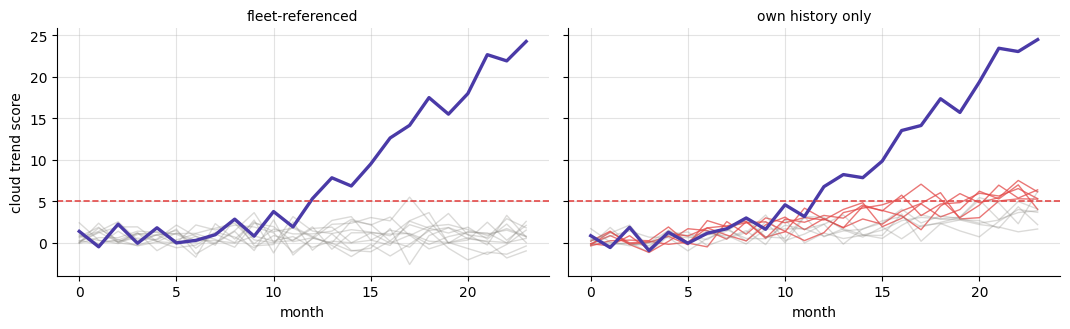

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(10.8, 3.4), sharey=True)
for panel, (score, title) in enumerate(((ft, "fleet-referenced"),
                                        (dt, "own history only"))):
    bad = detector_report(score, TREND_TH, DEG)["false_machines"]
    for m in range(score.shape[0]):
        if m == DEG:
            continue
        ax[panel].plot(score[m], lw=1.0, color=RED if m in bad else MUTED,
                       alpha=0.75 if m in bad else 0.3)
    ax[panel].plot(score[DEG], lw=2.4, color=VIOLET)
    ax[panel].axhline(TREND_TH, color=RED, ls="--", lw=1.2)
    ax[panel].set_xlabel("month")
    ax[panel].set_title(title, fontsize=10)
ax[0].set_ylabel("cloud trend score")
fig.tight_layout()
plt.show()

## 8. Retraining, and the four things that stop it being an improvement

Lecture 10 wrote `review_after_months: 12` into the alarm specification. Two years have
passed. Here is what happened to it.

In [25]:
def refit_baseline(X, quantile=0.99, persistence=(3, 5), months=12):
    """The Lecture 10 recipe, applied to whatever healthy history you kept."""
    mu, sd = X.mean(0), X.std(0)
    sd = np.where(sd > 0, sd, 1.0)
    z = np.abs((X - mu) / sd).max(1)
    return {"scaler_mean": mu.tolist(), "scaler_scale": sd.tolist(),
            "threshold": float(np.quantile(z, quantile)),
            "threshold_quantile": quantile,
            "persistence": {"m": persistence[0], "n": persistence[1]},
            "feature_names": list(FEATURE_NAMES),
            "fitted_on_healthy_windows": int(len(X)),
            "review_after_months": months}


def false_alarm_rate(spec, X):
    """Fraction of windows that exceed a spec's threshold."""
    mu = np.array(spec["scaler_mean"])
    sd = np.array(spec["scaler_scale"])
    z = np.abs((X - mu) / sd).max(1)
    return float(np.mean(z > spec["threshold"]))

In [26]:
spec_old = json.load(open("lecture10_alarm.json"))
healthy = lab == "normal"
recent = (mon >= 12) & (mon < 20)
test_h = healthy & (mon >= 20)                 # months the spec has never seen
test_f = (mach == DEG) & (mon >= 20)

print("the deployed spec, ageing:")
print(f"  false-alarm rate on months 0-7   {false_alarm_rate(spec_old, Xm[healthy & (mon < 8)]):.3f}")
print(f"  false-alarm rate on months 20-23 {false_alarm_rate(spec_old, Xm[test_h]):.3f}")
print()

SPECS = [("Lecture 10 spec (year 1)", spec_old),
         ("refit on labelled healthy history", refit_baseline(Xm[healthy & recent])),
         ("refit on everything recent", refit_baseline(Xm[recent]))]
out = pd.DataFrame([{"spec": n, "threshold": round(s["threshold"], 2),
                      "false alarms (healthy)": round(false_alarm_rate(s, Xm[test_h]), 3),
                      "alarms on the failing machine": round(false_alarm_rate(s, Xm[test_f]), 3)}
                    for n, s in SPECS]).set_index("spec")
print(out.to_string())

the deployed spec, ageing:
  false-alarm rate on months 0-7   0.025
  false-alarm rate on months 20-23 0.046

                                   threshold  false alarms (healthy)  alarms on the failing machine
spec                                                                                               
Lecture 10 spec (year 1)                4.04                   0.046                          0.619
refit on labelled healthy history       4.55                   0.017                          0.225
refit on everything recent              5.09                   0.015                          0.107


Read the last row carefully, because it is the trap.

Refitting on *everything recent* — the natural thing to write, since "recent data is
what the machines look like now" — produces the **best false-alarm rate on the table**
(0.015) and the **worst detector**
(0.107 against the original spec's
0.619). The failing machine's data was in the training window,
so the new baseline learned that a spalled bearing is normal.

The metric that improved is not the metric that matters. Lecture 10 opened with that
sentence about accuracy; it is the same mistake wearing different clothes.

Even the careful refit is not free: excluding the labelled faults still raises the
threshold from 4.04 to 4.55,
and buys the false-alarm rate back down from 0.046 to
0.017 **at the cost of** detection falling from
0.619 to 0.225. That may well be the
right trade — but it is a trade, and it must be stated.

### The four gates

1. **Exclude what alarmed.** A baseline fitted on data that includes the fault learns to
   accept the fault. Lecture 10 hit this with drift; here it is worse, because the fault
   is real.
2. **Hold out the future.** Score the candidate spec on months it has never seen, not on
   the window it was fitted to.
3. **Re-measure detection on every fault you have.** A spec that only improved its
   false-alarm rate has not improved.
4. **Write the expiry date on it.** The new spec ages exactly like the old one did.

And then the new spec has to get to the device — which is a downlink, and Lecture 13.

## 9. The real thing

Everything above ran against a stand-in. Here is the shipping code, which is in the lab
package and is not executed here because it needs credentials, WiFi and a broker.

### On the ESP32 — `net_pub.py`

Note what it does *not* do: it never blocks the control loop, it never lets a failed
publish raise, and `connect()` returning `False` is an acceptable outcome. The device
decides locally; the network is how it reports.

```python
"""
net_pub.py  --  Lecture 12, Lab 12
01211271 Industrial AI and IoT

The uplink, on the ESP32.  Real MicroPython, real NETPIE, real WiFi.

Add this to the Lecture 11 device and it publishes what the device decided --
not what the device measured.  Three topics, and a policy that decides which
of them to use and when:

    @msg/event      the situation changed
    @msg/summary    one heartbeat a minute, with a count in it
    @msg/feat       the raw features, in a short burst, only around an alarm

The counting heartbeat is the important one.  `ni` is how many windows in the
last minute alarmed with an impulsive driver, and it costs six bytes.  Without
it the cloud waits for the next event; with it the cloud knows within one
heartbeat.  Section 4 of the notebook measures the difference.

Fill in the four constants below from your NETPIE device page, copy this file
to the board next to features.py, model.py and alarm.py, and import it from
main.py.
"""
import gc
import json
import time

import network
from umqtt.simple import MQTTClient

import alarm

# ------------------------------------------------------------ your settings
WIFI_SSID = "Wokwi-GUEST"
WIFI_PASS = ""
DEVICE_ID = "<your NETPIE device id>"
DEVICE_TOKEN = "<your NETPIE token>"
DEVICE_SECRET = "<your NETPIE secret>"

BROKER = "broker.netpie.io"
PORT = 1883

TOPIC_FEAT = b"@msg/feat"
TOPIC_EVENT = b"@msg/event"
TOPIC_SUMMARY = b"@msg/summary"
TOPIC_SHADOW = b"@shadow/data/update"

SCHEMA_VERSION = 1
HEARTBEAT_S = 60                 # one summary a minute
DWELL_S = 15                     # at most one event every 15 s
SMOOTH = 32                      # windows of majority vote before believing it
BURST = 8                        # feature messages around a raise
IMPULSIVE = ("kurt", "crest", "e_hi", "e_bpfo")

# ... transport, messages and the Publisher policy class ...
```

The `Publisher` class is the policy from section 4, in a form that runs in constant
memory: five counters, a ring buffer of `BURST` feature vectors, and a smoothing window,
all preallocated.

### In Colab — `cloud_sub.py`

The subscriber applies the *same* alert rule the notebook used, appends every message to
a CSV so section 6 has a history to retrain from, and publishes its own verdict to
`@msg/cloud`.

```python
_hits = deque()
_alerted = False


def on_connect(client, userdata, flags, rc, *a):
    print("connected, rc =", rc)
    for t in SUB_TOPICS:
        client.subscribe(t)
        print("  subscribed", t)


def append_csv(body):
    """Keep everything.  Section 6: you cannot retrain on what you threw away."""
    new = not os.path.exists(CSV_PATH)
    with open(CSV_PATH, "a", newline="") as fh:
        w = csv.writer(fh)
        if new:
            w.writerow(["t", "kind", "label", "margin", "score", "driver",
                        "raised", "n", "ni"] + FEATURES)
        f = body.get("f", [None] * 12)
        w.writerow([body.get("t"), body.get("e", "feat" if "f" in body else "summary"),
                    body.get("l"), body.get("m"), body.get("a"), body.get("d"),
                    body.get("r"), body.get("n"), body.get("ni")] + list(f))


def evidence(body):
    """How many pieces of impulsive-alarm evidence this one message carries."""
    n = 1 if (body.get("r") and body.get("d") in IMPULSIVE) else 0
    return max(n, int(body.get("ni", 0)))


def on_message(client, userdata, msg):
    global _alerted
    try:
        body = json.loads(msg.payload.decode())
    except ValueError:
        print("unparseable payload on", msg.topic)
        return
    append_csv(body)

    now = body.get("t", time.time())
    k = evidence(body)
    for _ in range(k):
        _hits.append(now)
    while _hits and _hits[0] < now - ALERT_WINDOW:
        _hits.popleft()

    if len(_hits) >= ALERT_K and not _alerted:
        _alerted = True
        out = {"v": 1, "t": now, "alert": "bearing",
               "evidence": len(_hits), "window_s": ALERT_WINDOW,
               "driver": body.get("d")}
        client.publish(PUB_TOPIC, json.dumps(out))
        print("ALERT published:", out)
    elif len(_hits) == 0 and _alerted:
        _alerted = False
        client.publish(PUB_TOPIC, json.dumps({"v": 1, "t": now, "alert": "clear"}))
        print("cleared")

    print(f"{msg.topic:16s} {body.get('e', '-'):8s} "
          f"a={body.get('a', '-')!s:>7} d={body.get('d', '-'):9s} "
          f"r={body.get('r', 0)} ni={body.get('ni', '-')} "
          f"[evidence {len(_hits)}]")
```

## The protocol

Designing an uplink for a machine that already decides for itself:

1. **Write the schema first**, version it, and timestamp at the source.
2. **Measure a message on the wire**, not in memory — the topic goes with every one.
3. **Send the verdict as well as the evidence.** The cheap policies have nothing to send
   otherwise.
4. **Put the driver in the schema.** It is what separates a heavy cut from a spall, and
   it costs about eight bytes.
5. **Never publish per window by default.** Publish on change, with a heartbeat so
   silence is distinguishable from a dead device.
6. **Put a statistic in the heartbeat.** Counting the windows that mattered costs six
   bytes and recovers almost all the detection latency.
7. **Debounce and dwell.** A reporting rule is not an actuation rule; 15 events a second
   is an alarm system nobody reads.
8. **Keep the history you will need to retrain on.** The publish policy decides what the
   next model can learn.
9. **Give the cloud context, not a bigger model.** History and peers were worth six
   months here; subtract the plant-wide common mode or you will condemn healthy machines.
10. **Gate every retrain**: exclude what alarmed, hold out the future, re-measure
    detection, and write the expiry date on it.

## Exercises

1. **Your own heartbeat.** The counting heartbeat detects in one heartbeat interval.
   Sweep the interval from 10 s to 10 minutes and plot detection delay and bytes per
   hour against it. Where is the knee, and what would you set it to for a machine whose
   failure takes an hour to become dangerous?

2. **A second counter.** `ni` counts impulsive alarms. Add one more integer to the
   summary that would let the cloud distinguish a *growing* fault from a steady one
   within a single heartbeat. Measure what it costs and what it buys.

3. **The load change, harder.** Change `make_shift` so the heavy cut starts one minute
   *after* the spall. Does the cloud's rule still work? If not, what in the schema would
   you change — and is the answer more fields or a different rule?

4. **Binary payloads.** Replace the JSON feature message with a packed binary one
   (`struct.pack` of twelve float32 plus a byte of flags) and measure the saving. Then
   argue, in three sentences, whether it is worth the loss of being able to read the
   traffic with `mosquitto_sub`.

5. **Loss.** MQTT QoS 0 does not guarantee delivery. Drop a random 5 % of messages from
   each policy's stream and re-run the detection measurement. Which policy degrades
   worst, and why is it the one with the fewest messages?

6. **Store and forward.** The broker is unreachable for two hours. Design a bounded
   on-device queue that keeps the most valuable messages and drops the rest. State the
   RAM it needs and the rule that decides what "most valuable" means.

7. **The fleet reference, properly.** Section 7 subtracts the fleet *median*. Try the
   trimmed mean and a robust regression instead, and find how many machines the fleet
   needs before the reference is worth having. What happens with three machines?

8. **Towards Lecture 13.** The refitted spec of section 8 is 25 numbers, a threshold and
   a date. Write the downlink message that would carry it, decide which topic it belongs
   on, and say what the device must do if it arrives corrupted or half-received.

## References

**MQTT and IoT messaging**

* Banks, A. and Gupta, R., eds. (2014). *MQTT Version 3.1.1.* OASIS Standard. The
  packet layout section 2 is where `wire_bytes` comes from.
* Stanford-Clark, A. and Truong, H. L. (2013). *MQTT-SN Protocol Specification v1.2.*
  What the protocol looks like when bytes matter even more than they do here.
* NETPIE documentation: https://docs.netpie.io/ — topics, device shadow, data feed and
  the REST API used in section 6.

**Alarm management**

* ISA-18.2 (2016). *Management of Alarm Systems for the Process Industries.* The source
  of the debounce/dwell discipline in section 4; the alarm-flood material is the
  industrial version of the event storm we measured.
* EEMUA 191 (2013). *Alarm Systems: A Guide to Design, Management and Procurement.*
  Where the "an operator can handle about one alarm every ten minutes" figure comes
  from.

**Fleet monitoring and drift**

* Lee, J., Wu, F., Zhao, W., Ghaffari, M., Liao, L. and Siegel, D. (2014).
  *Prognostics and health management design for rotary machinery systems.* Mechanical
  Systems and Signal Processing, 42(1–2), 314–334. The fleet-reference idea of section 7.
* Gama, J., Žliobaitė, I., Bifet, A., Pechenizkiy, M. and Bouchachia, A. (2014).
  *A survey on concept drift adaptation.* ACM Computing Surveys, 46(4).
* Sculley, D. et al. (2015). *Hidden technical debt in machine learning systems.*
  NeurIPS. Section 8's gates, in the general case.

**Tools**

* Eclipse Paho Python client: https://eclipse.dev/paho/index.php?page=clients/python/
* MicroPython `umqtt.simple`:
  https://github.com/micropython/micropython-lib/tree/master/micropython/umqtt.simple

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>